# Rip Current Risk Prediction
### Predicting dangerous ocean conditions from real NOAA data

**Author:** Luke Ronningen
**September 2026**

Rip currents kill more people in the United States each year than hurricanes, tornadoes, or lightning. In 2024, 59 of 64 surf zone fatalities were caused by rip currents. This notebook builds a machine learning classifier that predicts daily rip current risk (Low / Moderate / High) for Orange County beaches using real, publicly available NOAA data:

- **Ocean conditions** from NDBC buoy 46222 (San Pedro, off Huntington Beach)
- **Tide data** from NOAA CO-OPS station 9410660 (Los Angeles)
- **Risk labels** from the NWS San Diego Surf Zone Forecast archive

**Run top to bottom** with Shift+Enter. Everything runs in your browser.

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import requests
import re
from io import StringIO

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


## 2. Fetch buoy data (ocean conditions)

Pull hourly readings from NDBC station 46222 for 2019–2025 and aggregate to daily. We use the daily **peak** wave height, since peak conditions drive rip current danger, and the daily mean for the other variables.

Note: station 46222 is a wave buoy — it measures waves, period, direction, and water temperature, but **not** wind or air pressure, so those columns will be empty. That's expected; we don't use them.

In [3]:
def fetch_ndbc(station_id, year):
    url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/historical/stdmet/"
    try:
        r = requests.get(url, timeout=30, headers={'User-Agent': 'Mozilla/5.0 (research)'})
        r.raise_for_status()
        lines = r.text.strip().split('\n')
        if len(lines) < 3:
            return None
        cols = lines[0].replace('#', '').strip().split()
        data = pd.read_csv(StringIO('\n'.join(lines[2:])), sep=r'\s+', header=None,
                           names=cols, na_values=['MM', '999', '99.0', '999.0', '9999'])
        ycol = 'YY' if 'YY' in data.columns else ('#YY' if '#YY' in data.columns else data.columns[0])
        tc = {ycol: 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour'}
        if 'mm' in data.columns:
            tc['mm'] = 'minute'
        if data[ycol].max() < 100:
            data[ycol] += 1900
        data['datetime'] = pd.to_datetime(data[list(tc)].rename(columns=tc), errors='coerce')
        ren = {'WVHT':'wave_height_m','DPD':'dominant_period_s','MWD':'mean_wave_dir_deg','WTMP':'water_temp_c'}
        data = data.rename(columns={k:v for k,v in ren.items() if k in data.columns})
        print(f"  {station_id} {year}: {len(data)} records")
        return data
    except Exception as e:
        print(f"  {station_id} {year}: {e}")
        return None

print("Fetching buoy data...")
frames = [fetch_ndbc('46222', y) for y in range(2019, 2026)]
real = pd.concat([f for f in frames if f is not None], ignore_index=True)
real['date'] = real['datetime'].dt.floor('D')

daily = real.groupby('date').agg(
    wave_height_m=('wave_height_m', 'max'),
    dominant_period_s=('dominant_period_s', 'mean'),
    mean_wave_dir_deg=('mean_wave_dir_deg', 'mean'),
    water_temp_c=('water_temp_c', 'mean'),
).reset_index()
print(f"\nAggregated to {len(daily)} daily records")
daily.head()

Fetching buoy data...
  46222 2019: 18360 records
  46222 2020: 17398 records
  46222 2021: 16650 records
  46222 2022: 17497 records
  46222 2023: 17285 records
  46222 2024: 17235 records
  46222 2025: 17480 records

Aggregated to 2538 daily records


,date,wave_height_m,dominant_period_s,mean_wave_dir_deg,water_temp_c
0,2019-01-01,1.66,8.143750,172.416667,16.193750
1,2019-01-02,0.86,13.330000,244.161290,15.922581
2,2019-01-03,0.67,14.012340,261.170213,15.870213
3,2019-01-04,0.88,13.550870,266.847826,15.826087
4,2019-01-05,1.26,14.539583,267.166667,15.475000


## 3. Fetch rip current risk labels (the target)

Download every San Diego Surf Zone Forecast (product SRFSGX) from the Iowa Environmental Mesonet archive and extract the **Orange County** (zone CAZ552), **nearest-term** rip current risk from each. We isolate the Orange County section and take the first day-block's rating, so we don't over-count high-risk days by mixing in San Diego County or multi-day outlooks.

In [4]:
def fetch_srf_labels(start="2019-01-01", end="2026-01-01"):
    url = "https://mesonet.agron.iastate.edu/cgi-bin/afos/retrieve.py"
    params = {"pil": "SRFSGX", "sdate": start, "edate": end, "fmt": "text", "limit": "9999"}
    print("Downloading forecasts from IEM archive (30-60 seconds)...")
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    return r.text

def parse_oc_rip_risk(text):
    """Nearest-term rip current risk for Orange County (CAZ552) only."""
    oc_match = re.search(r'CAZ552.*?(?=\$\$)', text, re.DOTALL)
    if not oc_match:
        return None
    oc_forecast = oc_match.group(0).split('&&')[0]  # drop the legend
    m = re.search(r'Rip Current Risk\*?[\.\s]*?(Low|Moderate|High)\b', oc_forecast, re.IGNORECASE)
    if m:
        return m.group(1).capitalize()
    label = re.search(r'Rip Current Risk', oc_forecast, re.IGNORECASE)
    if label:
        window = oc_forecast[label.end():label.end() + 80]
        m2 = re.search(r'\b(Low|Moderate|High)\b', window, re.IGNORECASE)
        if m2:
            return m2.group(1).capitalize()
    return None

raw = fetch_srf_labels()
products = re.split(r'\n(?=\w{6}\s+KSGX\s+\d{6})', raw)
print(f"Found {len(products)} forecast products")

records = []
for prod in products:
    date_match = re.search(r'\d{3,4}\s+(?:AM|PM)\s+\w+\s+\w+\s+(\w+)\s+(\d+)\s+(\d{4})', prod)
    risk = parse_oc_rip_risk(prod)
    if date_match and risk:
        month_str, day, year = date_match.groups()
        try:
            date = pd.to_datetime(f"{month_str} {day} {year}", format="%b %d %Y")
            records.append({'date': date, 'rip_risk_label': risk})
        except Exception:
            continue

labels = pd.DataFrame(records).drop_duplicates('date', keep='last')
labels['date'] = labels['date'].dt.floor('D')
labels['rip_current_risk'] = labels['rip_risk_label'].map({'Low': 0, 'Moderate': 1, 'High': 2})
labels = labels[['date', 'rip_risk_label', 'rip_current_risk']]

print(f"\nParsed {len(labels)} daily OC risk labels")
print(labels['rip_risk_label'].value_counts())
labels.head()

Found 5243 forecast products

Parsed 2557 daily OC risk labels
rip_risk_label
Moderate    997
Low         904
High        656
Name: count, dtype: int64


,date,rip_risk_label,rip_current_risk
1,2025-12-31,Low,0
3,2025-12-30,Low,0
5,2025-12-29,Low,0
7,2025-12-28,Low,0
9,2025-12-27,High,2


## 4. Add tide data

Rip currents strengthen near low tide, so tide is a physically important predictor. Pull hourly water levels from NOAA CO-OPS station 9410660 (Los Angeles, the closest long-record station) and build three daily features: the daily minimum level, the daily range, and the daily mean.

(The LA station is ~25 miles up the coast, so its tide timing is close but not identical to Huntington Beach — a small source of noise worth noting in the write-up.)

In [5]:
def fetch_tide_year(station, year):
    url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    params = {
        "begin_date": f"{year}0101", "end_date": f"{year}1231",
        "station": station, "product": "hourly_height", "datum": "MLLW",
        "time_zone": "lst", "units": "metric", "format": "json",
        "application": "rip_current_research",
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()
    if "data" not in js:
        print(f"  {year}: no data")
        return None
    tdf = pd.DataFrame(js["data"])
    tdf["datetime"] = pd.to_datetime(tdf["t"])
    tdf["tide_m"] = pd.to_numeric(tdf["v"], errors="coerce")
    print(f"  {year}: {len(tdf)} hourly readings")
    return tdf[["datetime", "tide_m"]]

print("Fetching tide data (one request per year)...")
tide_frames = [fetch_tide_year("9410660", y) for y in range(2019, 2026)]
tide = pd.concat([t for t in tide_frames if t is not None], ignore_index=True)
tide["date"] = tide["datetime"].dt.floor("D")

daily_tide = tide.groupby("date").agg(
    tide_min_m=("tide_m", "min"),
    tide_max_m=("tide_m", "max"),
    tide_mean_m=("tide_m", "mean"),
).reset_index()
daily_tide["tide_range_m"] = daily_tide["tide_max_m"] - daily_tide["tide_min_m"]
daily_tide = daily_tide.drop(columns=["tide_max_m"])

print(f"\nBuilt {len(daily_tide)} days of tide features")
daily_tide.head()

Fetching tide data (one request per year)...
  2019: 8760 hourly readings
  2020: 8784 hourly readings
  2021: 8760 hourly readings
  2022: 8760 hourly readings
  2023: 8760 hourly readings
  2024: 8784 hourly readings
  2025: 8760 hourly readings

Built 2557 days of tide features


,date,tide_min_m,tide_mean_m,tide_range_m
0,2019-01-01,0.078,0.915667,1.718
1,2019-01-02,-0.090,0.873167,1.890
2,2019-01-03,-0.165,0.888833,2.051
3,2019-01-04,-0.156,0.940250,2.100
4,2019-01-05,-0.141,0.967708,2.115


## 5. Join everything and sanity-check

Merge ocean conditions, tide, and risk labels on the date. Then the key test: do ocean conditions actually differ by risk level? If wave height and period climb from Low → Moderate → High, the labels carry real physical signal and the dataset is trustworthy.

In [6]:
merged = daily.merge(labels, on='date', how='inner').merge(daily_tide, on='date', how='left')
print(f"Joined dataset: {len(merged)} days")
print(f"Days missing tide data: {merged['tide_min_m'].isna().sum()}\n")

print("Risk distribution:")
print(merged['rip_risk_label'].value_counts())

print("\n--- Mean conditions by risk level (sanity check) ---")
check = merged.groupby('rip_risk_label')[
    ['wave_height_m', 'dominant_period_s', 'tide_min_m', 'water_temp_c']
].mean().round(2).reindex(['Low', 'Moderate', 'High'])
print(check)

Joined dataset: 2538 days
Days missing tide data: 0

Risk distribution:
rip_risk_label
Moderate    989
Low         899
High        650
Name: count, dtype: int64

--- Mean conditions by risk level (sanity check) ---
                wave_height_m  dominant_period_s  tide_min_m  water_temp_c
rip_risk_label                                                            
Low                      1.00              11.47        0.05         17.38
Moderate                 1.18              11.81        0.04         17.68
High                     1.63              12.96        0.06         17.24


## 6. Feature engineering

Build physically-motivated features from the raw measurements: wave energy, steepness, how perpendicular the waves are to shore, seasonality, and multi-day swell build-up — plus the tide features.

In [7]:
data = merged.copy().sort_values('date').reset_index(drop=True)

data['wave_energy_proxy'] = data['wave_height_m']**2 * data['dominant_period_s']
data['wave_steepness'] = data['wave_height_m'] / (1.56 * data['dominant_period_s']**2)
shore_normal = 200  # Huntington Beach faces ~SSW
data['shore_normal_component'] = np.cos(np.radians(data['mean_wave_dir_deg'] - shore_normal))
data['month'] = data['date'].dt.month
data['is_summer'] = data['month'].isin([5,6,7,8,9,10]).astype(int)
data['wave_height_3d_avg'] = data['wave_height_m'].rolling(3, min_periods=1).mean()
data['wave_height_change'] = data['wave_height_m'].diff().fillna(0)

feature_cols = [
    'wave_height_m', 'dominant_period_s', 'mean_wave_dir_deg', 'water_temp_c',
    'wave_energy_proxy', 'wave_steepness', 'shore_normal_component',
    'is_summer', 'wave_height_3d_avg', 'wave_height_change',
    'tide_min_m', 'tide_range_m', 'tide_mean_m',
]
print(f"{len(feature_cols)} features ready.")

13 features ready.


## 7. Train and compare models

Chronological train/test split (train on earlier years, test on later) to avoid data leakage. With three classes and "Moderate" as the most common, always guessing Moderate scores ~39% — that's the baseline to beat.

In [8]:
X = data[feature_cols]
y = data['rip_current_risk']
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]
print(f"Training on {len(X)} days, {len(feature_cols)} features\n")

split = int(len(X) * 0.7)
X_tr, X_te = X.iloc[:split], X.iloc[split:]
y_tr, y_te = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Baseline: always predict the most common class
baseline = (y_te == y_tr.mode()[0]).mean()
print(f"Baseline (always predict most common): {baseline:.3f}\n")

risk_labels = ['Low', 'Moderate', 'High']
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
}
results = {}
for name, model in models.items():
    if "Logistic" in name:
        model.fit(X_tr_s, y_tr); pred = model.predict(X_te_s)
    else:
        model.fit(X_tr, y_tr); pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    results[name] = {'accuracy': acc, 'y_pred': pred, 'model': model}
    print(f"{name}: test accuracy {acc:.3f}")
    print(classification_report(y_te, pred, target_names=risk_labels, digits=3))

Training on 2538 days, 13 features

Baseline (always predict most common): 0.341

Logistic Regression: test accuracy 0.585
              precision    recall  f1-score   support

         Low      0.720     0.543     0.619       326
    Moderate      0.457     0.608     0.521       260
        High      0.653     0.631     0.642       176

    accuracy                          0.585       762
   macro avg      0.610     0.594     0.594       762
weighted avg      0.614     0.585     0.591       762

Random Forest: test accuracy 0.575
              precision    recall  f1-score   support

         Low      0.728     0.525     0.610       326
    Moderate      0.442     0.612     0.513       260
        High      0.647     0.614     0.630       176

    accuracy                          0.575       762
   macro avg      0.605     0.583     0.584       762
weighted avg      0.611     0.575     0.581       762

Gradient Boosting: test accuracy 0.554
              precision    recall  f1-sco

## 8. What drives rip current risk?

Feature importance from the best model — which ocean conditions matter most for predicting risk.

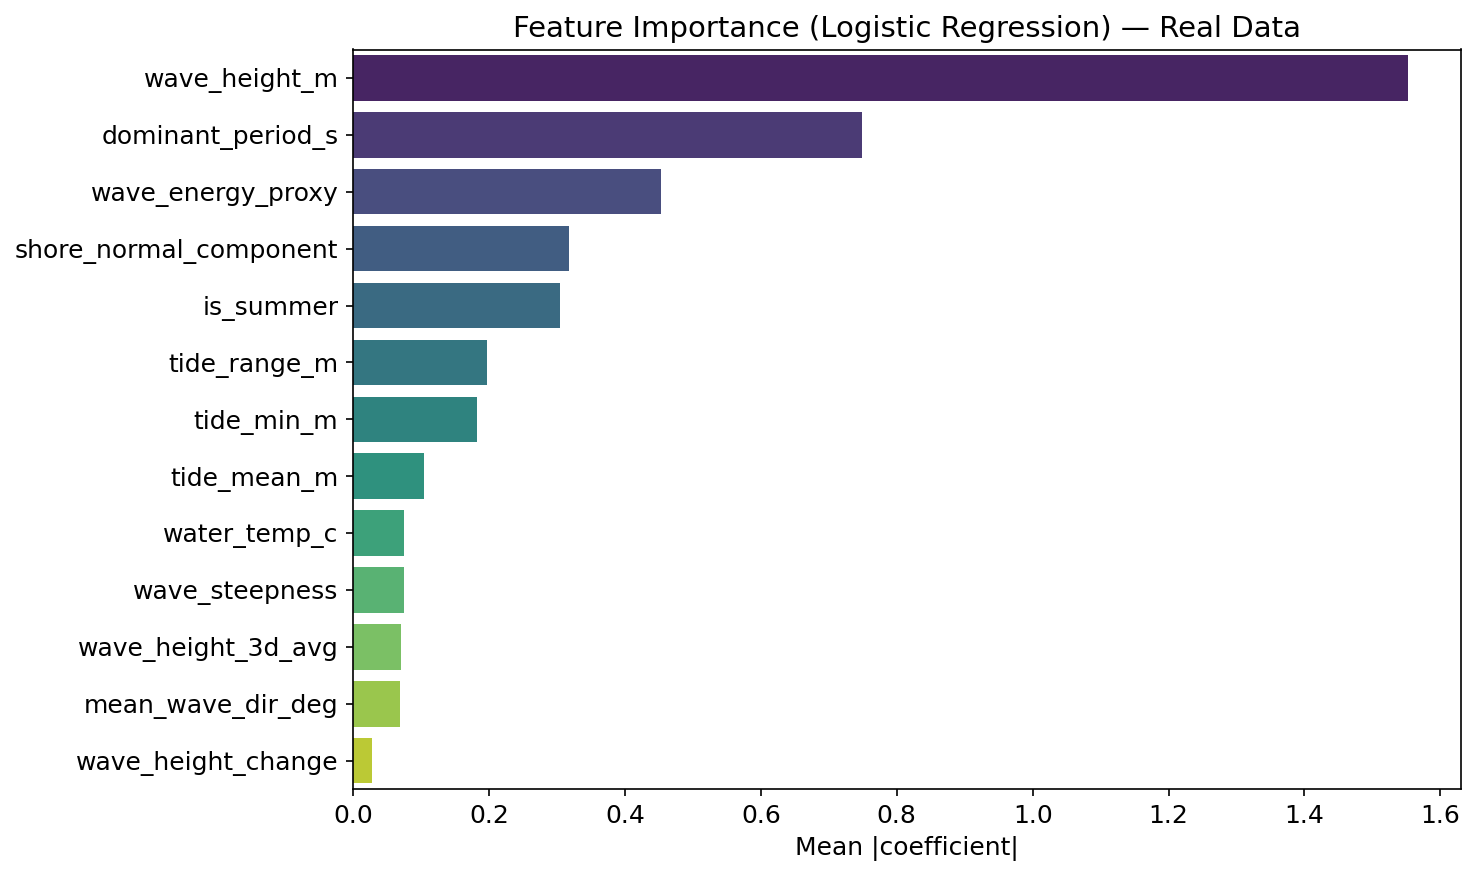

,feature,importance
0,wave_height_m,1.552664
1,dominant_period_s,0.748714
4,wave_energy_proxy,0.452880
6,shore_normal_component,0.318176
7,is_summer,0.304734
11,tide_range_m,0.196848
10,tide_min_m,0.181667
12,tide_mean_m,0.105078
3,water_temp_c,0.075128
5,wave_steepness,0.074868


In [9]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']

if hasattr(best_model, 'feature_importances_'):
    # Tree models: Gini importance
    importance_vals = best_model.feature_importances_
    importance_label = 'Importance'
else:
    # Logistic Regression: use magnitude of coefficients (averaged across the 3 classes)
    importance_vals = np.abs(best_model.coef_).mean(axis=0)
    importance_label = 'Mean |coefficient|'

feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance_vals
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title(f'Feature Importance ({best_name}) — Real Data')
plt.xlabel(importance_label); plt.ylabel('')
plt.tight_layout()
plt.show()

feat_imp

## 9. Confusion matrices

Where does each model get confused? For a safety tool, the important thing is that Low and High are rarely swapped — confusing the ambiguous Moderate middle with its neighbors matters far less than calling a dangerous day calm.

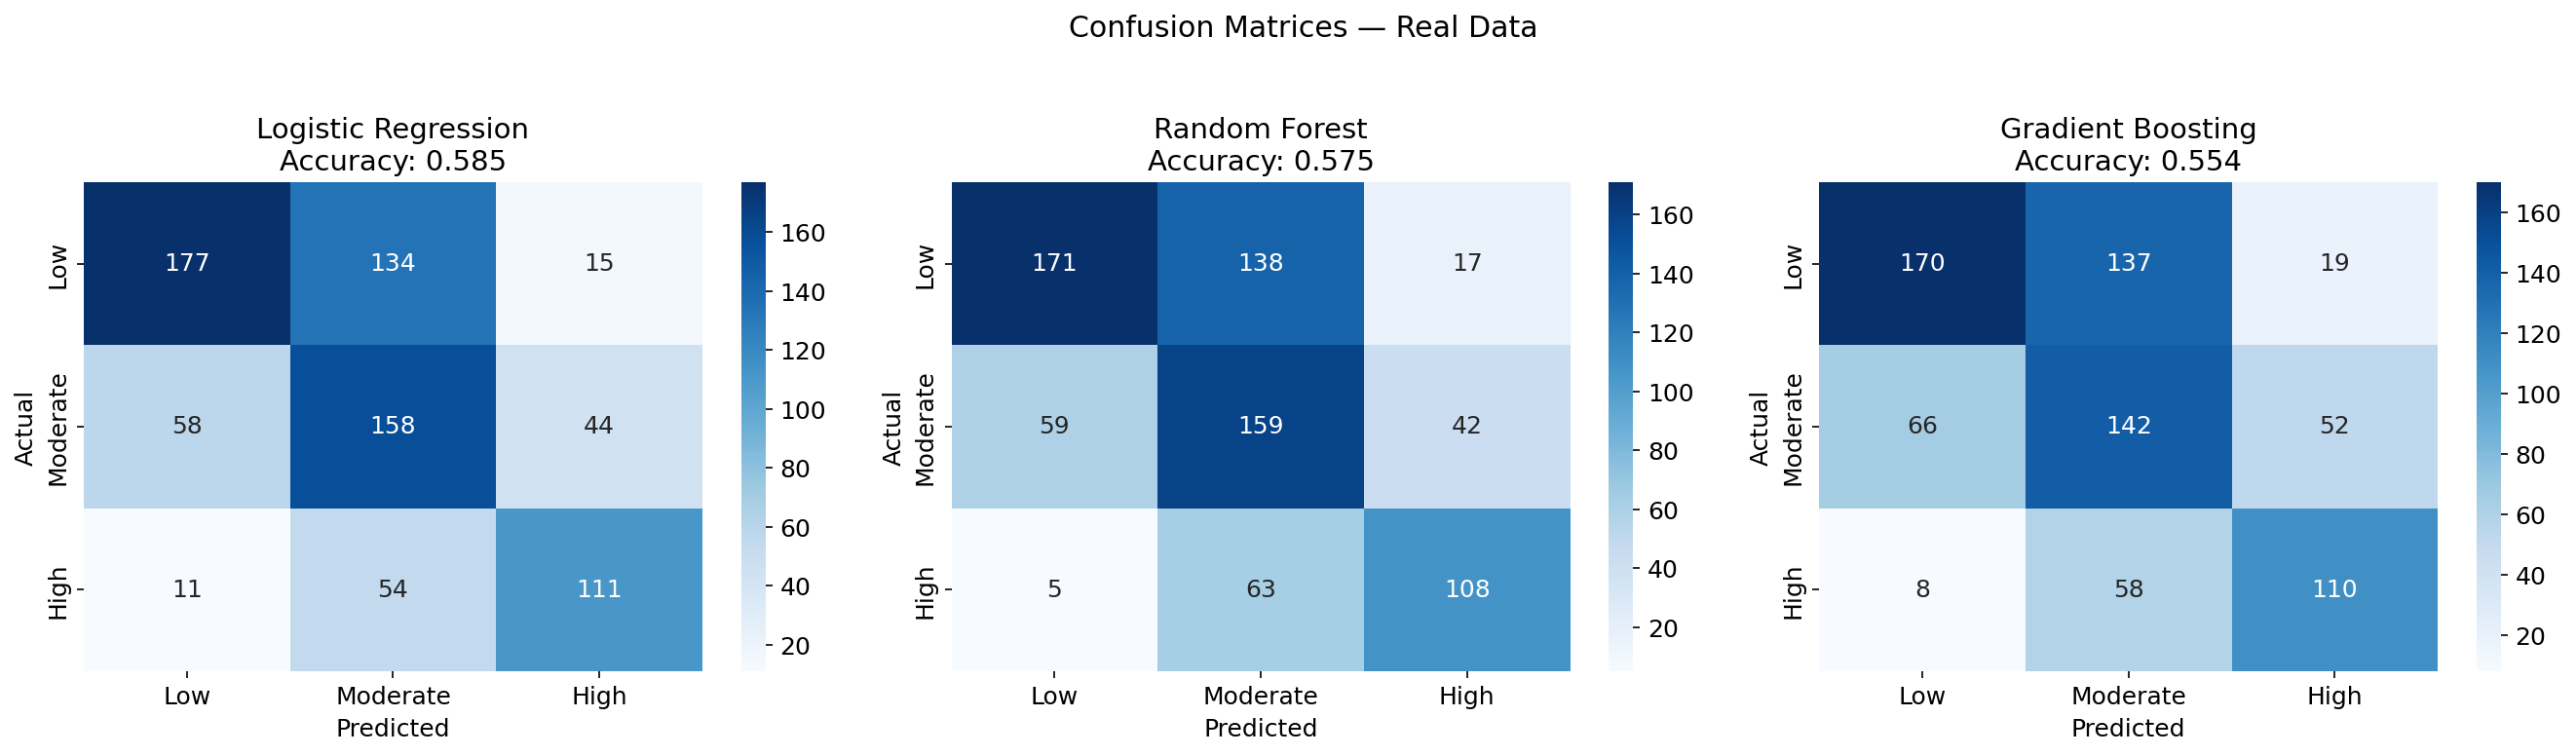

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_te, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=risk_labels, yticklabels=risk_labels, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.3f}')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices — Real Data', y=1.03)
plt.tight_layout(); plt.show()

## 10. Ocean conditions by risk level

How the key variables differ across Low / Moderate / High risk days.

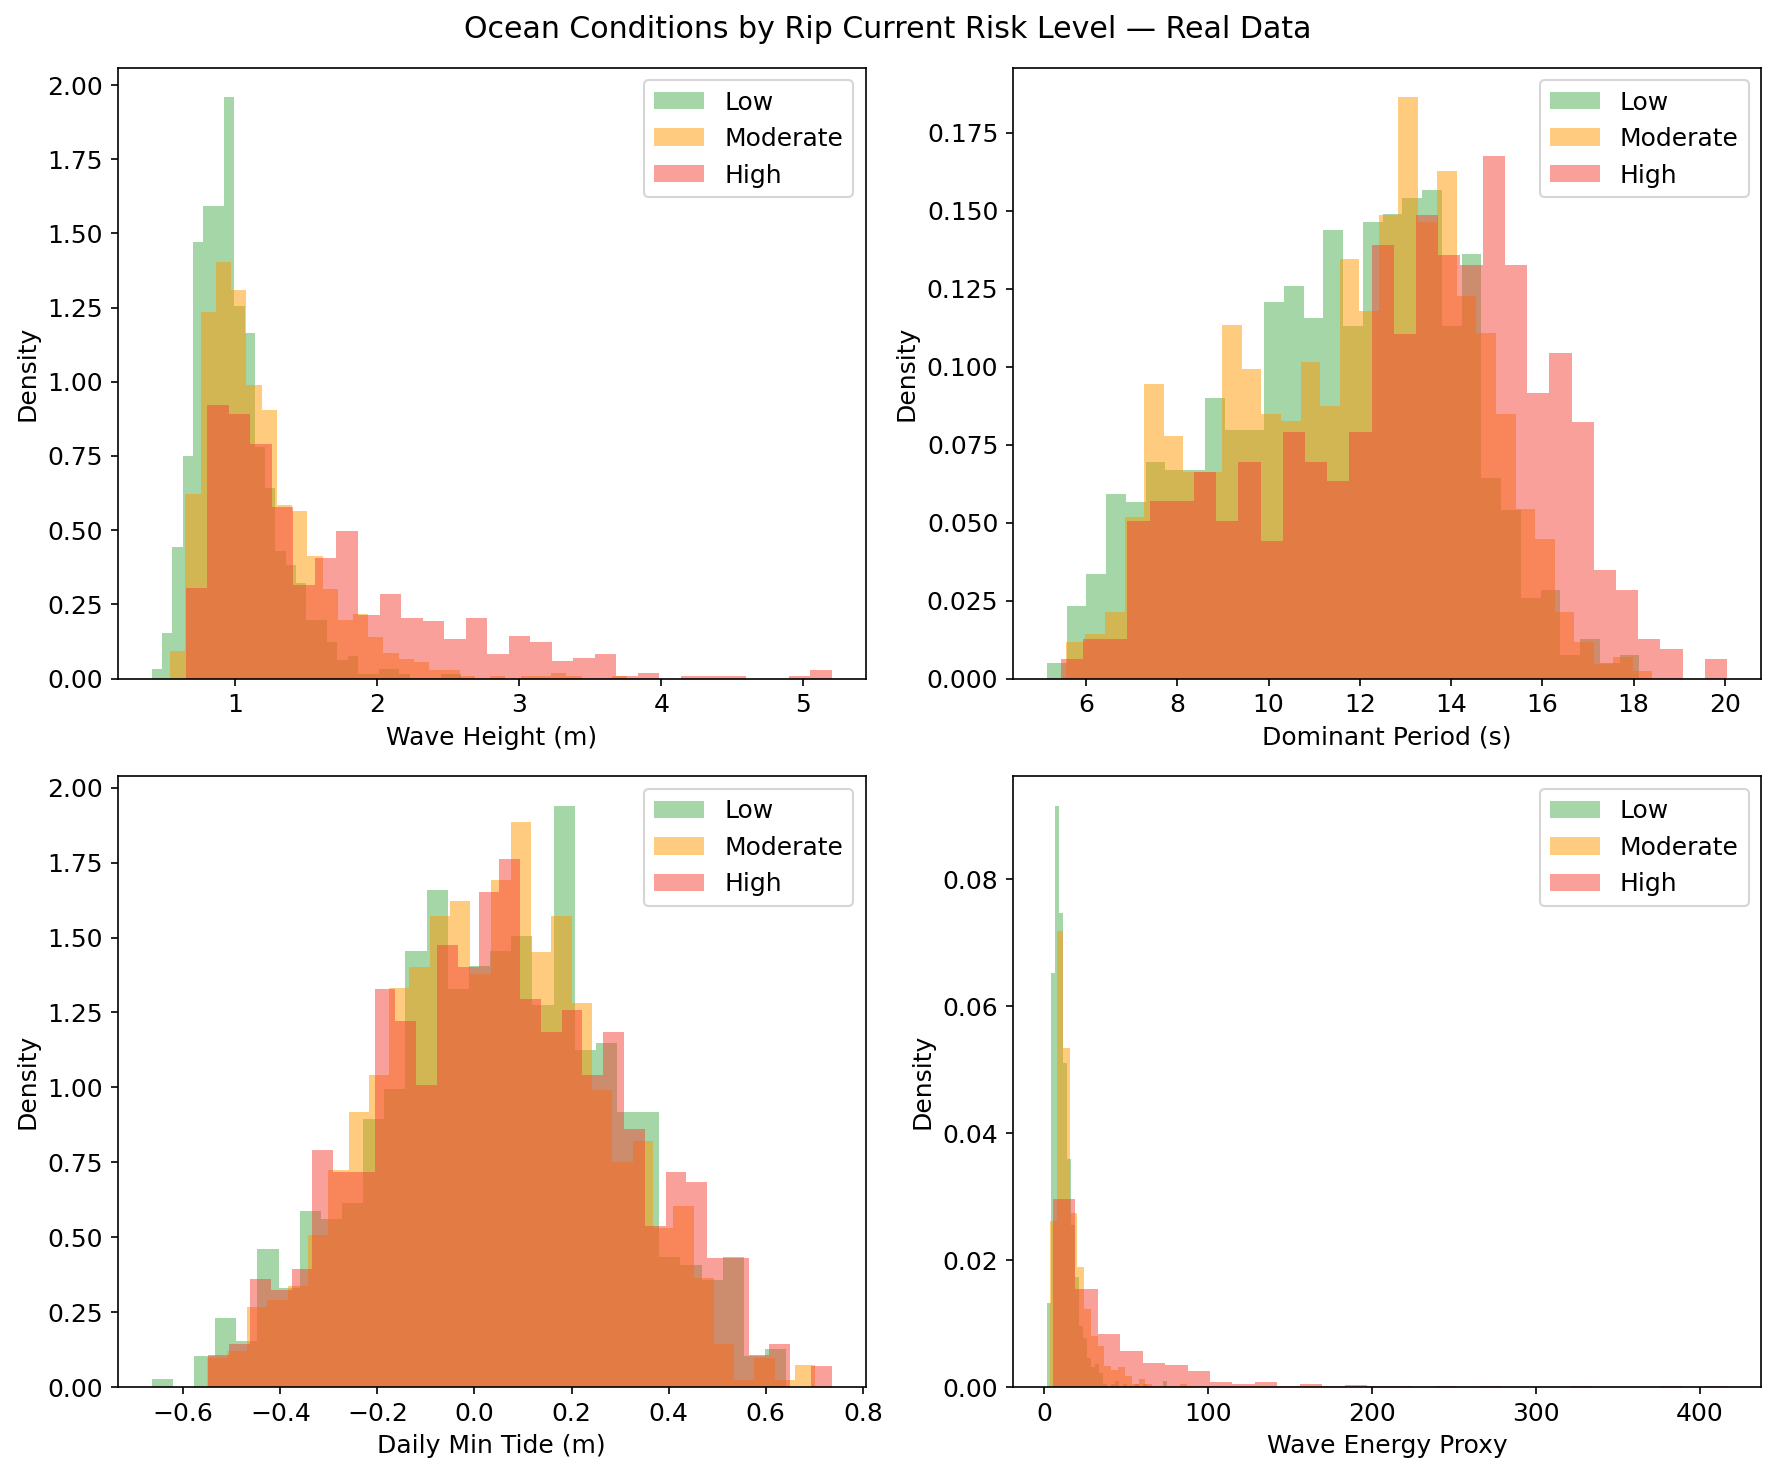

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col, title in zip(
    axes.flat,
    ['wave_height_m', 'dominant_period_s', 'tide_min_m', 'wave_energy_proxy'],
    ['Wave Height (m)', 'Dominant Period (s)', 'Daily Min Tide (m)', 'Wave Energy Proxy']
):
    for risk, color in zip([0, 1, 2], ['#4CAF50', '#FF9800', '#F44336']):
        ax.hist(data[data['rip_current_risk'] == risk][col].dropna(), bins=30, alpha=0.5,
                label=risk_labels[risk], color=color, density=True)
    ax.set_xlabel(title); ax.set_ylabel('Density'); ax.legend()
plt.suptitle('Ocean Conditions by Rip Current Risk Level — Real Data')
plt.tight_layout(); plt.show()

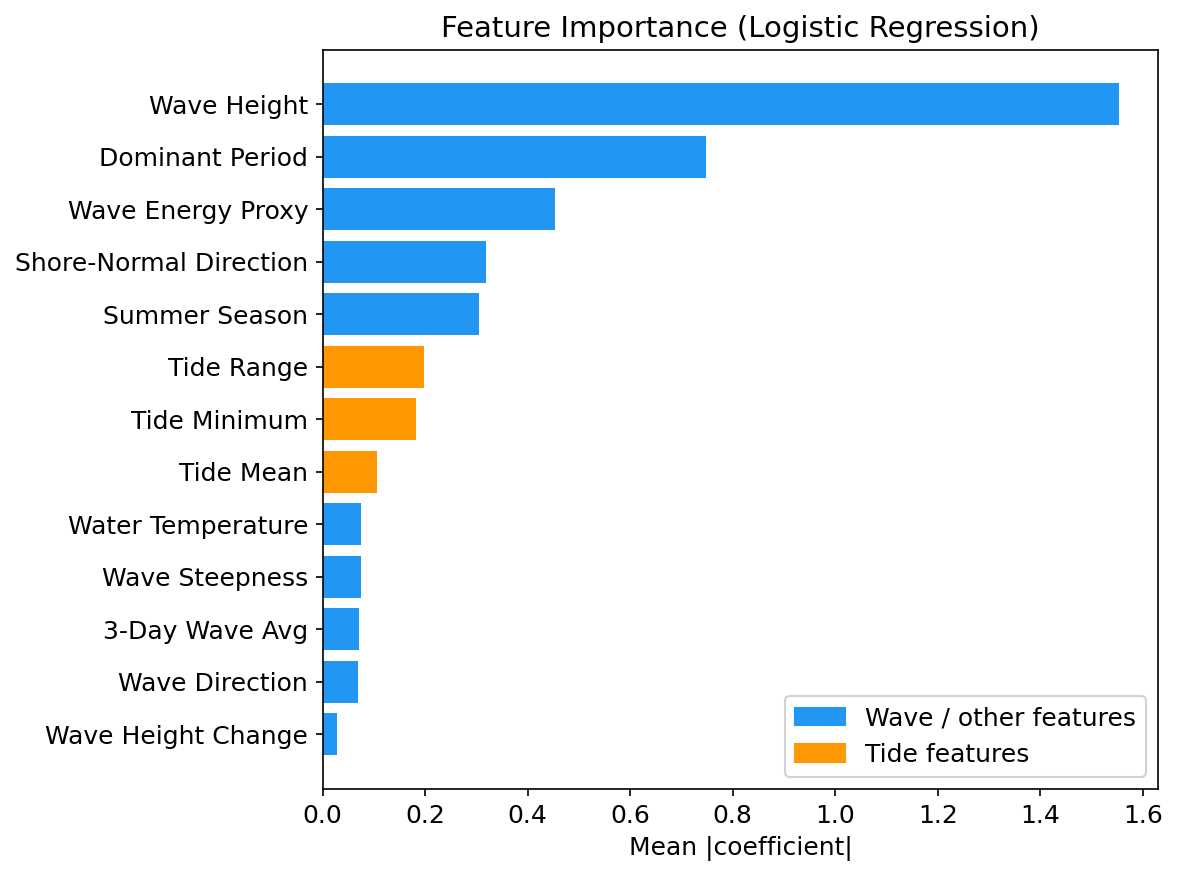

Saved: chart_feature_importance.png


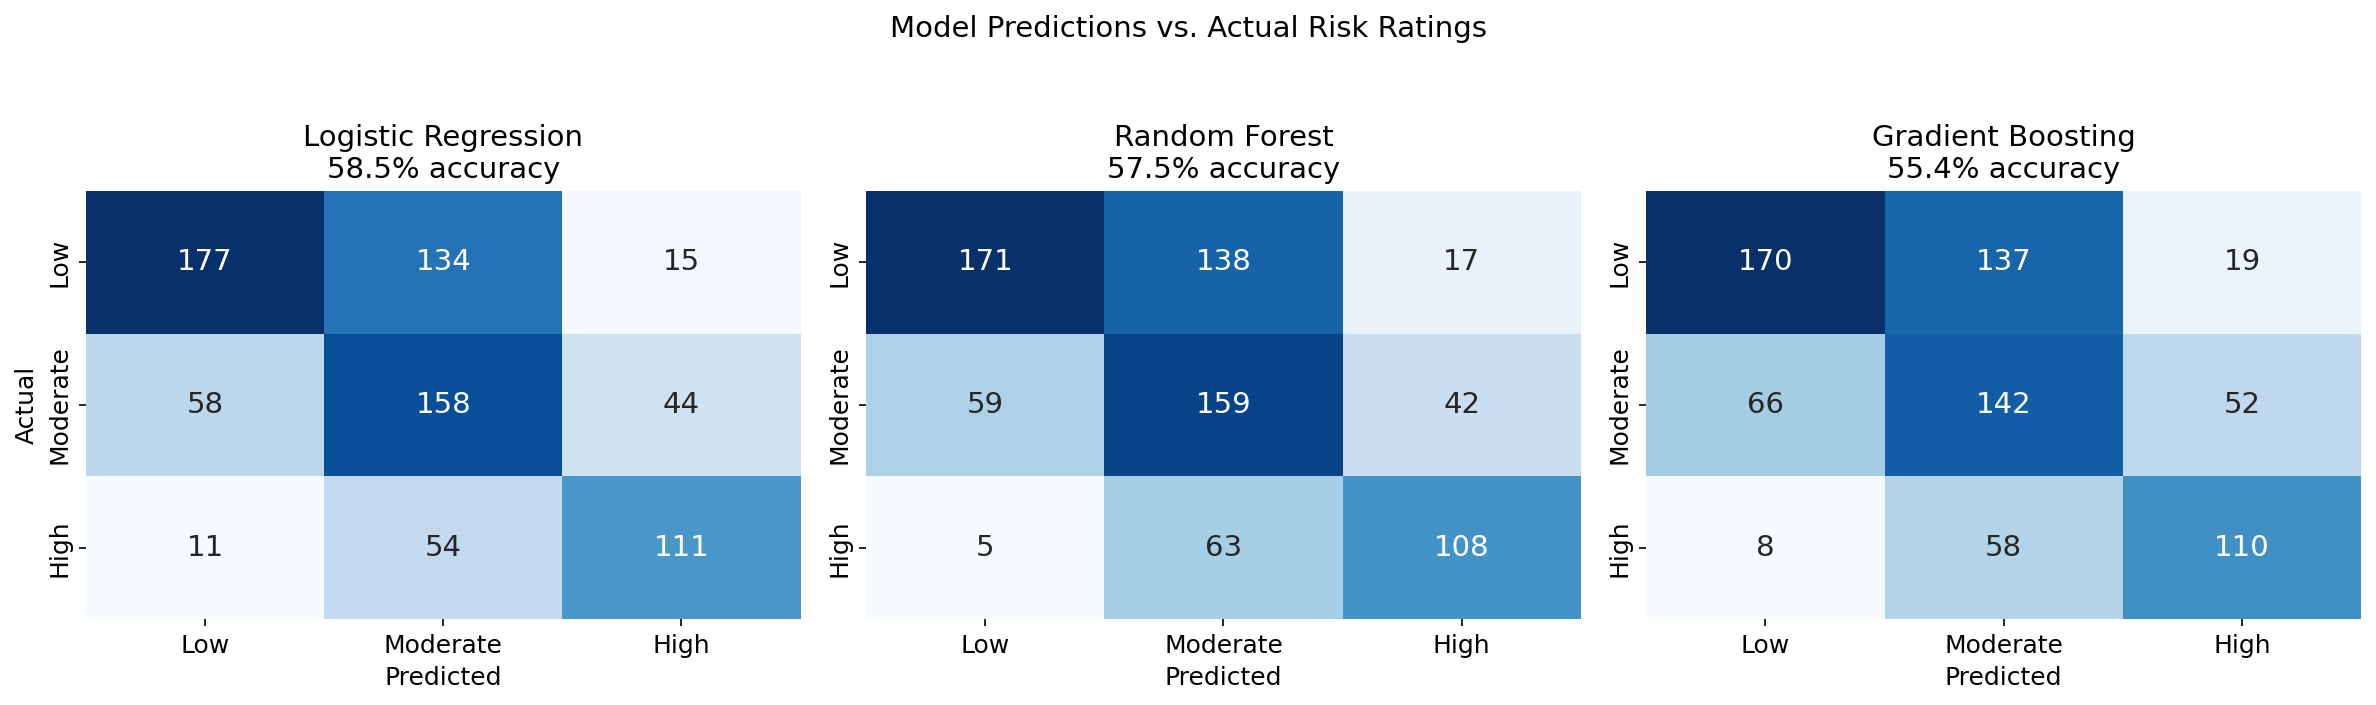

Saved: chart_confusion_matrices.png


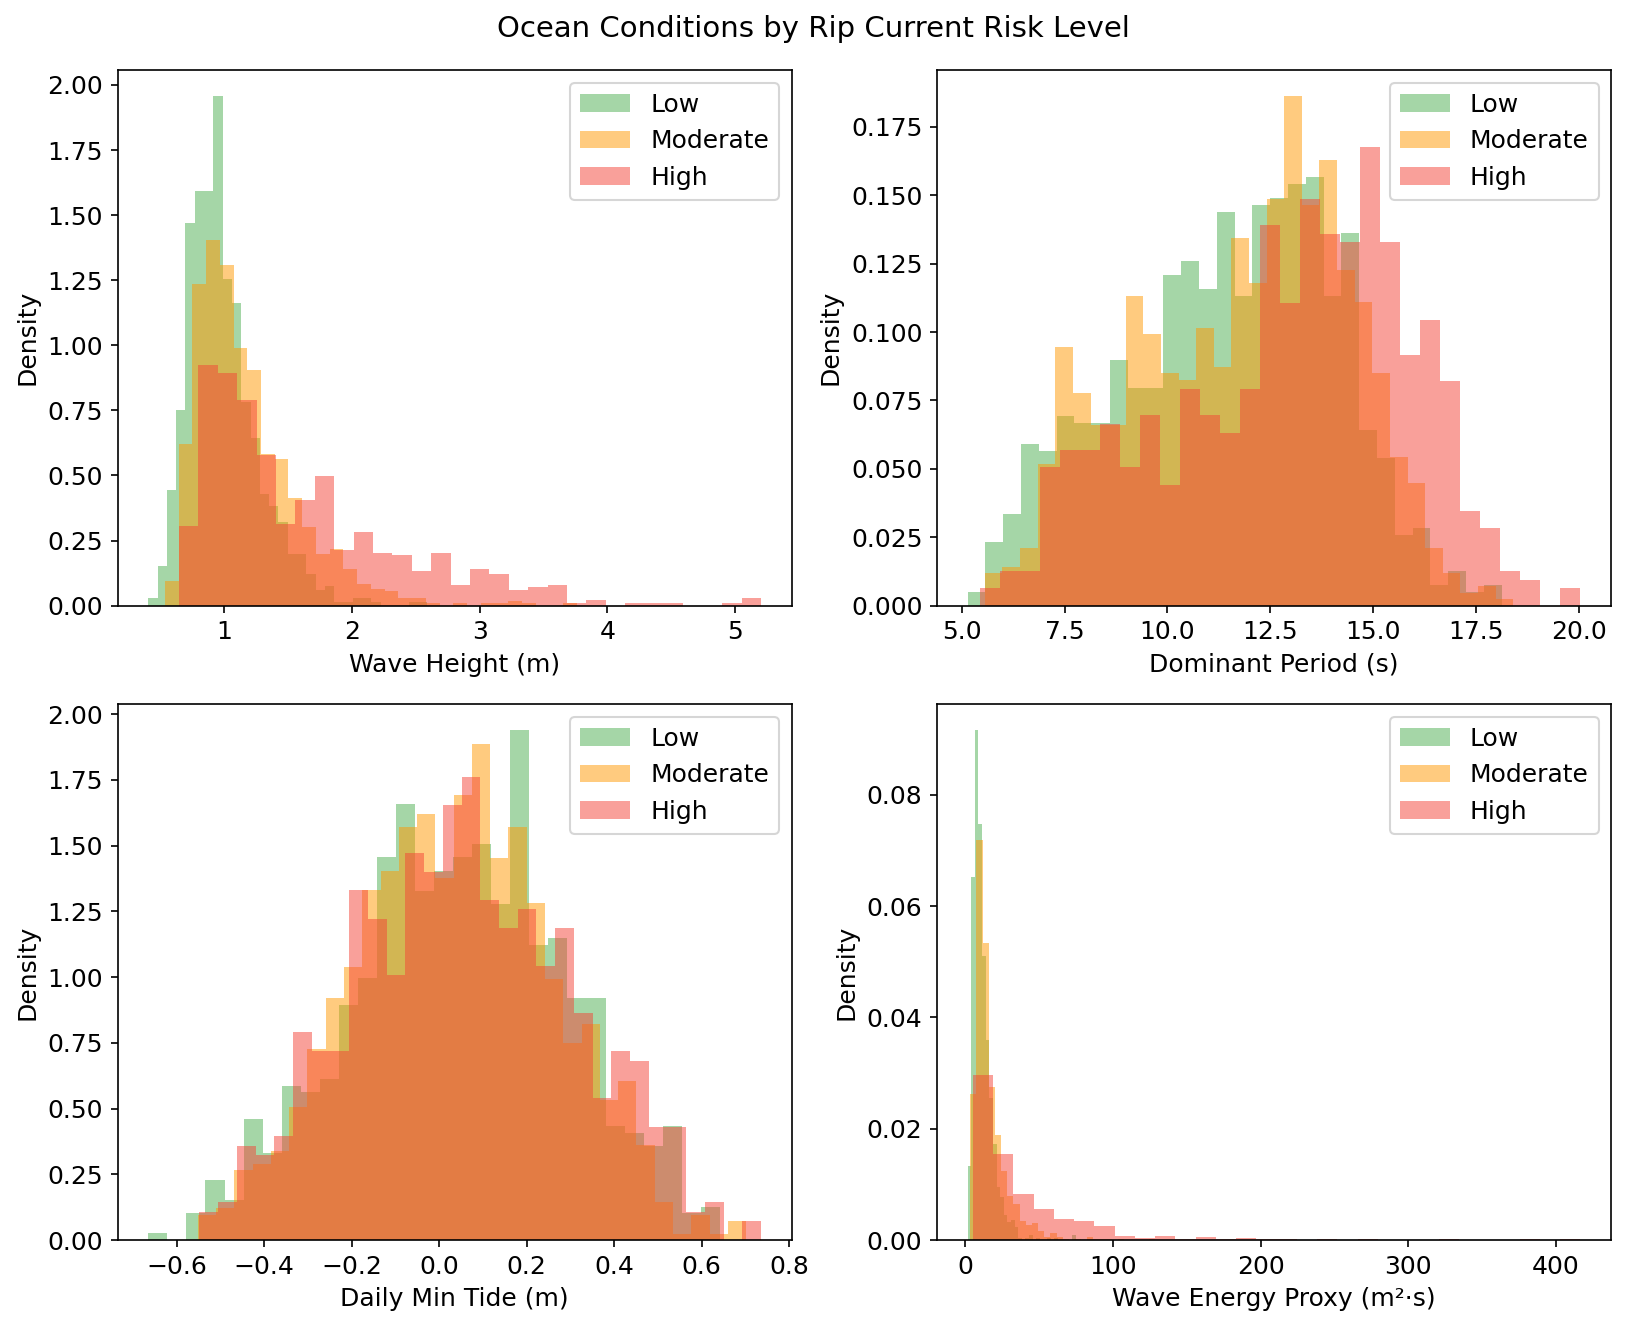

Saved: chart_conditions_by_risk.png


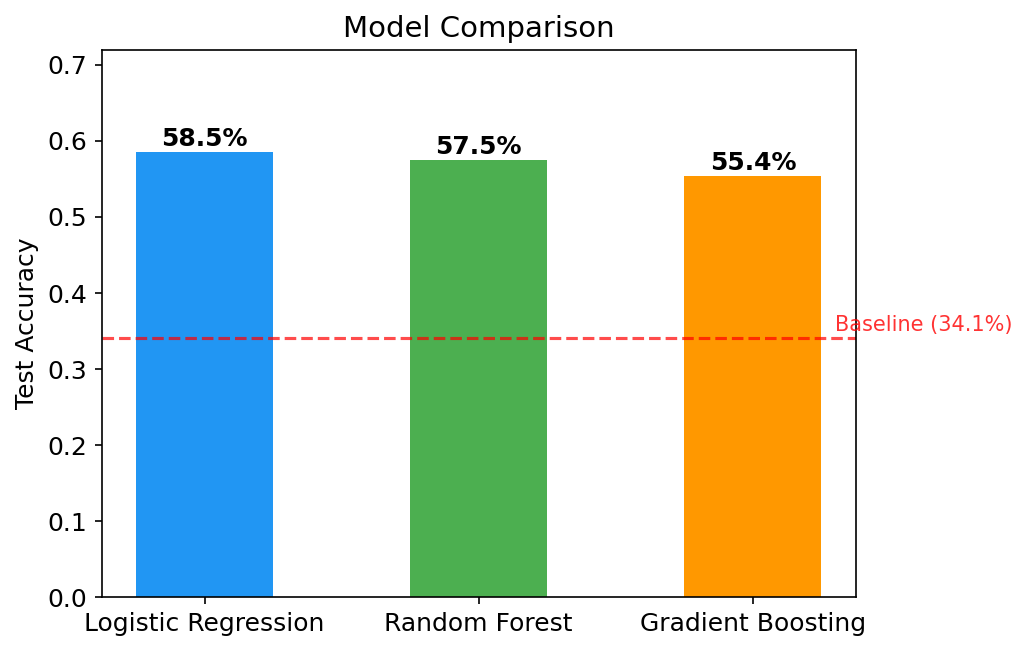

Saved: chart_model_comparison.png

── All 4 charts saved. Right-click each → Save Image to download. ──


In [12]:
# ── Publication-quality charts for TDS article ──
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np

matplotlib.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

risk_labels = ['Low', 'Moderate', 'High']

# ────────────────────────────────
# CHART 1: Feature Importance
# ────────────────────────────────
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']

if hasattr(best_model, 'feature_importances_'):
    imp_vals = best_model.feature_importances_
    imp_label = 'Importance'
else:
    imp_vals = np.abs(best_model.coef_).mean(axis=0)
    imp_label = 'Mean |coefficient|'

feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': imp_vals
}).sort_values('importance', ascending=True)  # ascending for horizontal bar

# Clean up feature names for display
name_map = {
    'wave_height_m': 'Wave Height',
    'dominant_period_s': 'Dominant Period',
    'wave_energy_proxy': 'Wave Energy Proxy',
    'shore_normal_component': 'Shore-Normal Direction',
    'is_summer': 'Summer Season',
    'tide_range_m': 'Tide Range',
    'tide_min_m': 'Tide Minimum',
    'tide_mean_m': 'Tide Mean',
    'water_temp_c': 'Water Temperature',
    'wave_steepness': 'Wave Steepness',
    'wave_height_3d_avg': '3-Day Wave Avg',
    'mean_wave_dir_deg': 'Wave Direction',
    'wave_height_change': 'Wave Height Change',
}
feat_imp['label'] = feat_imp['feature'].map(name_map).fillna(feat_imp['feature'])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3' if 'Tide' not in lab else '#FF9800' for lab in feat_imp['label']]
ax.barh(feat_imp['label'], feat_imp['importance'], color=colors)
ax.set_xlabel(imp_label)
ax.set_title(f'Feature Importance ({best_name})')

# Add a subtle legend for the tide highlighting
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2196F3', label='Wave / other features'),
                    Patch(color='#FF9800', label='Tide features')],
          loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('chart_feature_importance.png')
plt.show()
print("Saved: chart_feature_importance.png")


# ────────────────────────────────
# CHART 2: Confusion Matrices
# ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_te, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=risk_labels, yticklabels=risk_labels,
                ax=ax, cbar=False,
                annot_kws={'size': 14})
    ax.set_title(f'{name}\n{res["accuracy"]:.1%} accuracy')
    ax.set_ylabel('Actual' if ax == axes[0] else '')
    ax.set_xlabel('Predicted')
plt.suptitle('Model Predictions vs. Actual Risk Ratings', fontsize=14, y=1.04)
plt.tight_layout()
plt.savefig('chart_confusion_matrices.png')
plt.show()
print("Saved: chart_confusion_matrices.png")


# ────────────────────────────────
# CHART 3: Conditions by Risk Level
# ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plot_configs = [
    ('wave_height_m', 'Wave Height (m)'),
    ('dominant_period_s', 'Dominant Period (s)'),
    ('tide_min_m', 'Daily Min Tide (m)'),
    ('wave_energy_proxy', 'Wave Energy Proxy (m²·s)'),
]
colors_risk = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}

for ax, (col, title) in zip(axes.flat, plot_configs):
    for risk_val, risk_name in enumerate(risk_labels):
        subset = data[data['rip_current_risk'] == risk_val][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=risk_name,
                color=colors_risk[risk_name], density=True)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Ocean Conditions by Rip Current Risk Level', fontsize=14)
plt.tight_layout()
plt.savefig('chart_conditions_by_risk.png')
plt.show()
print("Saved: chart_conditions_by_risk.png")


# ────────────────────────────────
# CHART 4: Model Comparison Bar Chart
# ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
model_names = list(results.keys())
accs = [results[n]['accuracy'] for n in model_names]

bars = ax.bar(model_names, accs, color=['#2196F3', '#4CAF50', '#FF9800'], width=0.5)
ax.axhline(y=0.341, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(2.3, 0.35, 'Baseline (34.1%)', color='red', fontsize=10, alpha=0.8)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison')
ax.set_ylim(0, 0.72)
plt.tight_layout()
plt.savefig('chart_model_comparison.png')
plt.show()
print("Saved: chart_model_comparison.png")

print("\n── All 4 charts saved. Right-click each → Save Image to download. ──")

## 11. Notes for the write-up

Things worth being honest about in the article (this transparency is what makes a data science piece credible):

- **The buoy is ~20 miles offshore** from where rips actually form, so it captures the incoming swell but not local surf-zone specifics.
- **Labels are forecaster judgments,** not measured ground truth — and the NWS leans conservative (when in doubt, warn), which shapes the class balance.
- **"Moderate" is inherently fuzzy** — it's the overlap zone, which is exactly where the model struggles most.
- **The tide station is ~25 miles away,** adding minor timing noise.

**Possible next step:** overlay the NWS surf-zone fatality data — were conditions on actual fatal days flagged high-risk by the model? That's a powerful closing section.